# Estimating Time to Payment for Receivables

# Data Prep and Exploratory Data Analysis for Assets dataset

THe given iput for modelling of payment behavior in CrediPay is a parquet file comprising 1001023 invoices (identified by the combination of asset_id + invoice_id) of 681 sellers from the platform  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
assets = pd.read_parquet('../data/df_assets.parquet', engine='pyarrow')

In [3]:
unique_sellers = assets['seller_tax_id'].nunique()
print("Unique buyer_tax_id count:", unique_sellers)

Unique buyer_tax_id count: 681


In [4]:
assets.head()

,asset_id,invoice_id,face_value,buyer_tax_id,seller_tax_id,maturity_date,due_date,settled_at,created_at,reference_date
0,5c764ad8-59dc-e30a-9d73-b051582605fb,9c3673c7cbbddde1,534.41,40199547791118,60259422305974,2025-04-10,2025-04-10,2025-04-06,2025-03-13,2025-04-15
1,b947a6c4-6e17-a418-091d-c04952f85047,23ba3b2f6e5570da,165.14,40519406990678,00925347588806,2024-12-24,2024-12-24,2024-12-22,2024-12-03,2025-03-19
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,c2d4b28ddd0da663,432.55,38842652921056,14133781557079,2024-02-02,2024-02-02,2024-02-01,2024-01-26,2025-03-20
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,2e6921011ecf24f1,102.60,54929917112999,14133781557079,2023-03-08,2023-03-08,2023-03-07,2023-02-28,2025-03-20
4,3ee1a83eb0ba837d,f32ba85be54f4160,6739.70,51211364716527,87924474238085,2024-08-08,2024-08-08,2024-08-06,2024-06-24,2025-02-03


In [5]:
assets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001023 entries, 0 to 1001022
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   asset_id        1001023 non-null  object        
 1   invoice_id      1001023 non-null  object        
 2   face_value      1001023 non-null  float64       
 3   buyer_tax_id    1001023 non-null  object        
 4   seller_tax_id   1001023 non-null  object        
 5   maturity_date   1001023 non-null  object        
 6   due_date        1001023 non-null  object        
 7   settled_at      888504 non-null   datetime64[ns]
 8   created_at      997487 non-null   datetime64[ns]
 9   reference_date  1001023 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 76.4+ MB


As seen above, some of the date fields are not in proper  date format.
 
Below, all necessary columns are transformed in proper datetime fields

In [6]:
assets['maturity_date'] = pd.to_datetime(assets['maturity_date'])
assets['due_date'] = pd.to_datetime(assets['due_date'])
assets['reference_date'] = pd.to_datetime(assets['reference_date'])

---

A small fraction of the dataset (3536 records) do not contain a valid "created_at" field. 

For puprposes of modeling, these rows will not be include in the dataset as they are noninformative and will not allow obtaining a duration for the payment under analysis

In [7]:
assets_no_creation_date = assets.loc[assets.created_at.isnull()]
assets_no_creation_date.head()


,asset_id,invoice_id,face_value,buyer_tax_id,seller_tax_id,maturity_date,due_date,settled_at,created_at,reference_date
192,8b14856e-81d4-12d1-121e-dd184d44624d,38e430ce823410ca,508.36,81594288290338,16790620976050,2024-09-24,2024-09-24,2024-09-23,NaT,2024-10-18
446,28791c85-7c19-26b2-2afe-a7d761ff6ee4,c331aadd0d787702,265.77,76273056899998,16790620976050,2024-10-03,2024-10-03,2024-10-01,NaT,2024-10-18
513,2792164e-1418-b756-ecc3-f375bee75fd1,3bbe999935b85fc4,95.20,79175872783030,16790620976050,2024-09-21,2024-09-21,2024-09-21,NaT,2024-10-18
722,4363d0ec-b9f9-04a3-eb5a-f22b81320fcf,dff2a443bf446a52,488.68,91850482823519,16790620976050,2024-11-02,2024-11-02,NaT,NaT,2024-10-18
1028,2e73ce93-8a42-dc2a-f20a-ba5074c6149e,0647b22621ac40e3,403.97,16207289689363,16790620976050,2024-08-09,2024-08-09,2024-08-06,NaT,2024-10-18


In [8]:
assets_no_creation_date.asset_id.shape[0]

3536

In [9]:
assets = assets.loc[~assets.created_at.isnull()]

---

Also, more inconsistencies were found regarding payments settled before invoice creation, which were also dropped out (17069 entries)

In [10]:
assets_settled_before_creation = assets.loc[assets['settled_at'] < assets['created_at']]
assets_settled_before_creation.head()

,asset_id,invoice_id,face_value,buyer_tax_id,seller_tax_id,maturity_date,due_date,settled_at,created_at,reference_date
15,e37f4d5d2311e287,9971a944f489f4c0,8730.85,88798121823961,20783772356477,2023-04-08,2023-04-08,2023-04-08,2023-05-05,2023-09-30
27,395facb5-6072-2424-274a-c7b6ab45e552,d4b576b61ce90faa,1821.19,04576048260798,32000772773675,2023-11-06,2023-11-06,2023-10-29,2023-10-30,2024-10-29
59,0a1c7e9c-f3b5-3e1e-4bee-76d22f77d0d4,d114da10f37b8784,4172.89,67027787761419,32000772773675,2024-05-15,2024-05-15,2024-05-13,2024-05-15,2024-11-14
94,185fea56-712d-5511-2227-26137d39ddf1,daf47c443d5a67a1,194.52,97657227874112,14133781557079,2024-02-26,2024-02-26,2024-02-18,2024-02-19,2025-03-20
114,84182548819097,6f5c8d0e991076a1,930000.00,20561897417779,66270349769454,2024-08-10,2024-08-10,2024-07-10,2024-07-11,2025-02-07


In [11]:
assets_settled_before_creation.shape

(17069, 10)

In [12]:
assets = assets.loc[~(assets['settled_at'] < assets['created_at'])]

---

And finally, some entries had a reference date maeked before the creation_date of the asset. These records (240) were also removed 

In [13]:
assets_reference_before_creation = assets.loc[assets['created_at'] > assets['reference_date']]
assets_reference_before_creation

,asset_id,invoice_id,face_value,buyer_tax_id,seller_tax_id,maturity_date,due_date,settled_at,created_at,reference_date
5424,04d10c1b73674b54,26ea0eef8fe61cd0,8625.92,03600041347396,13469743835956,2024-03-22,2024-03-22,2024-03-20,2024-03-07,2024-03-01
5610,3b4d06587800ad41,5dc5fc13d304ba59,724.50,51552550140006,38537894264356,2024-04-10,2024-04-10,NaT,2024-03-13,2024-03-01
9072,d7ee0faf516f7992,f8b0667c203a20b0,869.22,54114595343284,38537894264356,2024-04-01,2024-04-01,NaT,2024-03-04,2024-03-01
11459,c1b01d7bc1a7541b,31c9386fc098561b,575.28,85379969249379,38537894264356,2024-03-25,2024-03-25,2024-03-24,2024-03-11,2024-03-01
28307,2c17e1359f9b7a9a,3d2588fbb49dc240,1685.83,31541615783075,13469743835956,2024-04-06,2024-04-06,NaT,2024-03-14,2024-03-01
...,...,...,...,...,...,...,...,...,...,...
990262,63a7c74c762d30d4,ec25c9357133f549,290.00,32837879248448,13469743835956,2024-03-16,2024-03-16,2024-03-16,2024-03-06,2024-03-01
992308,e22d84f5eec26831,4942f0dd70354ea6,233.56,34395982710629,38537894264356,2024-03-19,2024-03-19,2024-03-17,2024-03-05,2024-03-01
994923,d8395c41d4337d07,371e630740d4edc6,877.64,05090459899160,13469743835956,2024-04-15,2024-04-15,NaT,2024-03-15,2024-03-01
996131,d5d58e7743fc1681,c9bcd777d428ed12,703.90,28812305311817,13469743835956,2024-03-20,2024-03-20,2024-03-19,2024-03-04,2024-03-01


In [14]:
assets_reference_before_creation.shape

(240, 10)

In [15]:
assets = assets.loc[~(assets['created_at'] > assets['reference_date'])]

---

With the assets dataset cleansed, we move on to exploratory analysis on assets payment data for CrediPay.

In [16]:
assets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980178 entries, 0 to 1001022
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   asset_id        980178 non-null  object        
 1   invoice_id      980178 non-null  object        
 2   face_value      980178 non-null  float64       
 3   buyer_tax_id    980178 non-null  object        
 4   seller_tax_id   980178 non-null  object        
 5   maturity_date   980178 non-null  datetime64[ns]
 6   due_date        980178 non-null  datetime64[ns]
 7   settled_at      868146 non-null  datetime64[ns]
 8   created_at      980178 non-null  datetime64[ns]
 9   reference_date  980178 non-null  datetime64[ns]
dtypes: datetime64[ns](5), float64(1), object(4)
memory usage: 82.3+ MB


In [17]:
assert assets['created_at'].notnull().all(), "There are missing values in 'created_at'"
assert (assets['settled_at'] > assets['created_at']).any(), "'settled_at' is greater than 'created_at' in some rows"
assert (assets['created_at'] < assets['reference_date']).any(), "'created_at' is greater than 'reference_date' in some rows"

With all setup, Time to move on to Duration table setup

duration_days is calculated based on time difference in days of ("settled at" or "reference date", for unpaid invoicess) and "created_at"

"paid" is a flag for the event of interest

"late_payment" is a flag for payments made after due date. It is not strictly necessary for model construction, but will be used for exploratory purposes only.

In [18]:
duration_table  = assets[['asset_id', 'buyer_tax_id', 'face_value' ,'created_at', 'settled_at' ,'due_date',  'reference_date']]

duration_table["duration_days"] = np.where(
    duration_table["settled_at"].isnull(),
    (duration_table["reference_date"] - duration_table["created_at"]).dt.days,
    (duration_table["settled_at"] - duration_table["created_at"]).dt.days
)

duration_table['paid'] = np.where(duration_table['settled_at'].isnull(), 0, 1)

duration_table['late_payment'] = np.where(
    (duration_table['paid'] == 1) & (duration_table['settled_at'] > duration_table['due_date']),
    1,
    0
)

In [19]:
duration_table.head(10)

,asset_id,buyer_tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment
0,5c764ad8-59dc-e30a-9d73-b051582605fb,40199547791118,534.41,2025-03-13,2025-04-06,2025-04-10,2025-04-15,24.0,1,0
1,b947a6c4-6e17-a418-091d-c04952f85047,40519406990678,165.14,2024-12-03,2024-12-22,2024-12-24,2025-03-19,19.0,1,0
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,38842652921056,432.55,2024-01-26,2024-02-01,2024-02-02,2025-03-20,6.0,1,0
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,54929917112999,102.60,2023-02-28,2023-03-07,2023-03-08,2025-03-20,7.0,1,0
4,3ee1a83eb0ba837d,51211364716527,6739.70,2024-06-24,2024-08-06,2024-08-08,2025-02-03,43.0,1,0
5,34ff0791-cf60-abe9-61fc-128af36e80fb,99548865378216,93000.00,2024-02-22,2024-04-24,2024-04-26,2024-10-01,62.0,1,0
6,d0c86ee5-cbfd-fc62-aaa0-6a4c282e4668,26384082403227,1988.80,2024-04-29,2024-09-01,2024-07-29,2024-11-19,125.0,1,1
7,bc45ac40-9219-9255-1f25-fd143cfd7a19,51929968703090,124.48,2023-08-31,2023-10-04,2023-09-08,2025-03-20,34.0,1,1
8,047388a0-5328-e748-da58-ecc8e31fbb5a,60902965699185,527.90,2025-03-27,NaT,2025-05-08,2025-04-15,19.0,0,0
9,544e1cc7-b1c9-0426-0e01-a518f469fba7,19194067326271,115.15,2023-03-08,2023-03-19,2023-03-19,2025-03-20,11.0,1,0


making a further sanity check for duration table! (null values indicate data quality issues on input)

In [20]:
assert (duration_table.duration_days > 0).any(), "Negative durations are not allowed. Check your input data!"

As we are using this duration table for further analysis and model development, it will be persisted in the "/data/output" path}

In [21]:
duration_table.to_parquet('../data/output/assets_duration_table.parquet')

---

This portfolio has 11% of unpaid loans and about 10 million reais in the observed time period. Our gaols aims to understand customer behavior and mitigate defaults.

In [38]:
pct_volume = duration_table.paid.value_counts(normalize=True)
pivot = pd.DataFrame({
    'count_invoice': duration_table.groupby('paid')['face_value'].count(),
    'prop_invoice': pct_volume,
    'sum_invoice': duration_table.groupby('paid')['face_value'].sum(),
 })

pivot

,count_invoice,prop_invoice,sum_invoice
paid,,,
0,112032,0.114298,1.085554e+08
1,868146,0.885702,1.120053e+09


In order to understand in general terms our portfolio, a Kaplan-Meier survival table and its related  curve are generated

In [23]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(durations=duration_table['duration_days'],

         event_observed=duration_table['paid'])

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 980178 total observations, 112032 right-censored observations>

In [24]:
survival_table = kmf.survival_function_
survival_table.head()

,KM_estimate
timeline,
0.0,0.995966
1.0,0.991203
2.0,0.984836
3.0,0.976539
4.0,0.961945


We sse that payment flow in the early days seems to be ok. As we move for medium and long runs (after ~100 days) the risk profile of the portfolio seems to quickly degradate. At a first sight, it seems that there 3 behaviors

* Sellers who pay quickly (0 up to 60 days)
* Sellers who need special attention regarding credit policies (60-100 days)
* Sellers with chronic cash flow (from 100 days and beyond)

The behavior of the curve after this elbow at about 100 days line, indicates that the risk profile kept constant in a low rate of future payment.

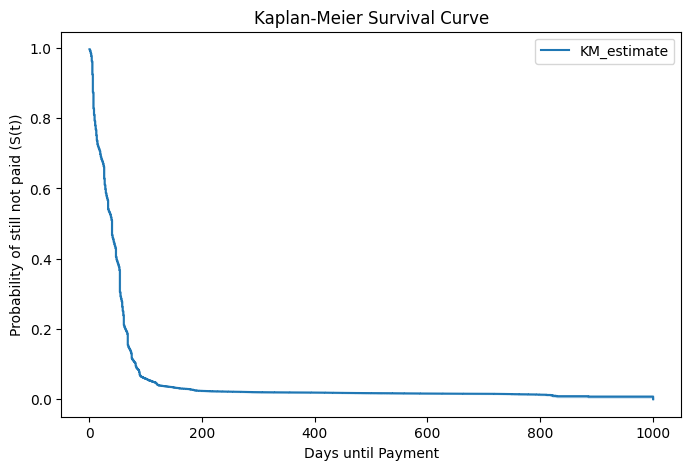

In [25]:
plt.figure(figsize=(8,5))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Days until Payment")
plt.ylabel("Probability of still not paid (S(t))")
plt.show()

Testing the  Kaplan-Meier fit, segmenting good payers and payers who delay (put are not censored), it can be seen more clearly the pattern of a steady curve after 100 days needed for payment. The late payers group has a significantly lower tendency to pay as time goes by 

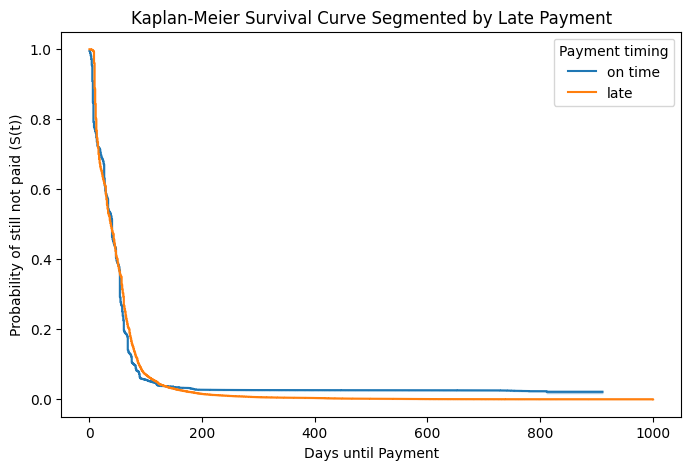

In [26]:
labels_map = {0: "on time", 1: "late"}

plt.figure(figsize=(8,5))
for grp in sorted(duration_table['late_payment'].unique()):
    df_grp = duration_table[duration_table['late_payment'] == grp]
    kmf = KaplanMeierFitter()
    kmf.fit(df_grp["duration_days"], df_grp["paid"], label=labels_map.get(grp, f"grp_{grp}"))
    kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve Segmented by Late Payment")
plt.xlabel("Days until Payment")
plt.ylabel("Probability of still not paid (S(t))")
plt.legend(title="Payment timing")
plt.show()

---